In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

# **Lab 8 - Higher dimensions: MINNs and PCA-Net**

So far with have dealt with parametrized PDEs where the number of parameters was significantly smaller than the FOM dimension, $p\ll N_h$. Now, we would like to say something about possible approaches that can tackle the case $p\approx N_h$.

In general, while the DL-ROM approach can be used, employing an autoencoder may not be as beneficial as before, since the solution manifold $\mathcal{S}=\{u_\boldsymbol{\mu}\}_{\boldsymbol{\mu}}$ is not "intrisically low-dimensional" anymore. For this reason, here, we shall focus on variants / extensions of the POD-NN technique. Before discussing possible approaches, we start by presenting a motivating example, which will serve as a test case for the remainder of the lab.

## Motivating example

We consider a simplified Darcy flow model featuring a spatially distributed parameter (permeability field), namely

$$\begin{cases}-\nabla\cdot(\mu\nabla u) = f & \text{in}\;\Omega\\-\nabla p\cdot\boldsymbol{n}\equiv0 & \text{on}\;\partial\Omega\\\int_{\Omega}p=0\end{cases}$$

where $\Omega\subset\mathbb{R}^{2}$ is the spatial domain, $u:\Omega\to\mathbb{R}$ is the pressure field and $\boldsymbol{n}$ is the unit normal, and $\mu:\Omega\to(0,+\infty)$ is the permeability field, **our parameter**.

For this case study, $\mu$ has been modeled using a random field for which

$$0.1\le \mu(x) \le 10.1 \forall x\in\Omega\quad\text{and}\quad \mu\in\mathcal{C}(\Omega),$$

holds $\mathbb{P}$-almost surely. Specifically, the latter was constructed as

$$\mu = 10\mathcal{S}(D e^{-\gamma Z})+0.1$$

where

- $\gamma=1/4$,
- $D:\Omega\to[0,+\infty)$ is a deterministic map, related to the "point-to-boundary-distance",
- $Z$ is a centered Gaussian random field with isotropic covariance kernel $\kappa(r)=e^{-100r^2}$,
- $\mathcal{S}$ is a scaling operator. Precisely, if $g\in\mathcal{C}(\Omega)$ is nonconstant, then $\mathcal{S}(g)$ is defined as

$$\mathcal{S}(g):=\frac{g-\min_{\boldsymbol{x}\in\Omega}g(\boldsymbol{x})}{\max_{\boldsymbol{x}\in\Omega}g(\boldsymbol{x})-\min_{\boldsymbol{x}\in\Omega}g(\boldsymbol{x})}.$$

We are interested in learning the map

$$\mathcal{C}(\Omega)\ni\mu\mapsto u\in L^{2}(\Omega),$$

that maps the permeability field onto the corresponding pressure field. Here, we define $\Omega$ to be a simplified 2D chart of the Elba Island.

For the source term, instead, we consider a superposition of three pointwise sources (of fixed position and intensity),

$$f = \sum_{i=1}^{3}\delta_{\boldsymbol{x}_i},$$

where $\delta_{\boldsymbol{x}_i}$ denotes the Dirac delta at $\boldsymbol{x}_i$.

In [2]:
import gdown
gdown.download(id = "1Fx0BJbggyoFS344kEsl3M2QroLYg2Cp1", output = "elba_dataset.npz")
gdown.download(id = "16n2zKU9xjhO0LY5Ddeov0DXTfJaO4oV4", output = "elba_mesh.xml")
clc()

In [12]:
dataset = np.load("elba_dataset.npz")
mu, u = dataset['mu'], dataset['u']

In [13]:
mu.shape, u.shape

((1000, 9550), (1000, 9550))

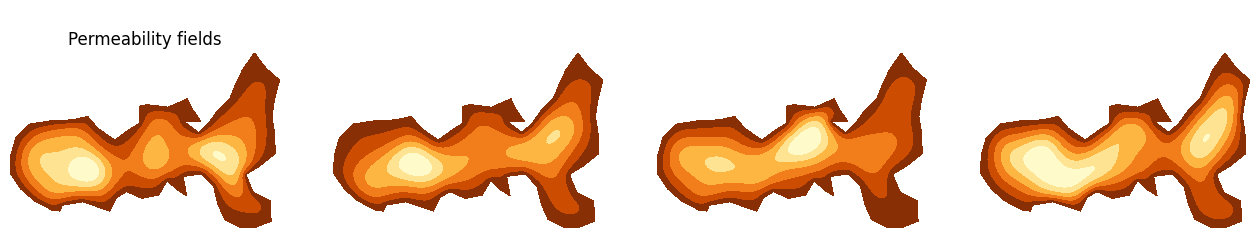

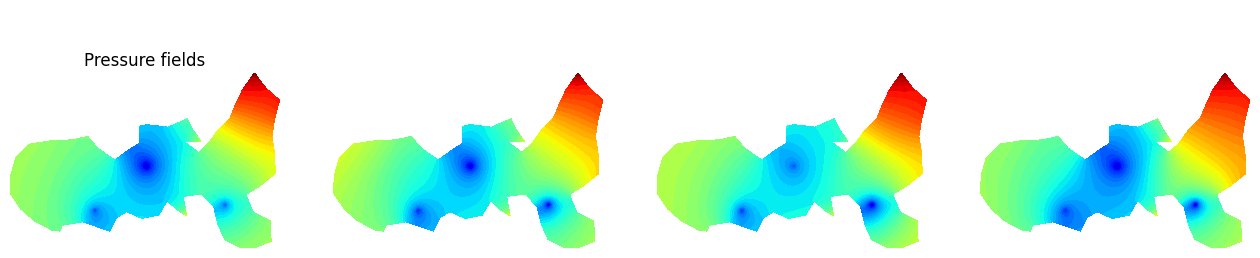

In [14]:
from IPython.display import clear_output as clc
import matplotlib.pyplot as plt

mesh = fe.loadmesh("elba_mesh.xml")
Vh = fe.space(mesh, "CG", 1)
clc()

fe.multiplot(mu[:4], (1, 4), Vh, levels = 7, cmap = 'YlOrBr_r')
plt.subplot(1, 4, 1)
plt.title("\nPermeability fields")

fe.multiplot(u[:4], (1, 4), Vh, levels = 50)
plt.subplot(1, 4, 1)
plt.title("\n\nPressure fields")
None

# Preliminary analysis via POD

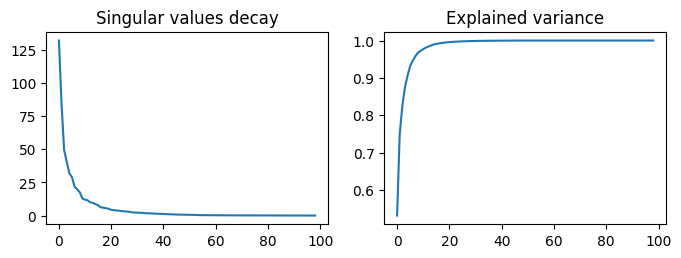

In [15]:
from scipy.linalg import svd
ntrain = 800
X, s, _ = svd(u[:ntrain].T, full_matrices = False)

plt.figure(figsize = (8, 2.5))
plt.subplot(1, 2, 1)
plt.plot(s[1:100])
plt.title("Singular values decay")
plt.subplot(1, 2, 2)
plt.plot(np.cumsum(s[1:100]**2)/np.sum(s[1:]**2))
plt.title("Explained 'variance'")
plt.show()

In [16]:
n = 15
V = X[:, :n]

In [17]:
V.shape

(9550, 15)

In [18]:
u, V = dv.tensor(u, V)
l2 = L2(Vh)
if(dv == GPU):
  l2.cuda()
clc()

In [19]:
utest = u[ntrain:]
uproj = utest @ V @ V.T
print("POD projection error using %d modes: %s." % (n, num2p(mre(l2)(utest, uproj))))

POD projection error using 15 modes: 1.97%.


## PCA-Net

The idea behind PCA-Net [1] is to perform a POD compression **also** over the **input field**, in an attempt to re-cast the problem within the "$p\ll N_h$" framework. Notice, in fact, that if we introduce a POD projector $\mathbf{Z}$ for $\boldsymbol{\mu}$ then

$$\boldsymbol{\mu}\approx \mathbf{Z}\mathbf{Z}^\top\boldsymbol{\mu}.$$

In particular, if $\mathbf{Z}\in\mathbb{R}^{p\times m}$, this allows us to formally replace $\boldsymbol{\mu}\in\mathbb{R}^p$ with

$$\boldsymbol{\mu}_{\text{small}}:=\mathbf{Z}^\top\boldsymbol{\mu}\in\mathbb{R}^m.$$

Now the idea is to train a neural network $\psi:\mathbb{R}^{m}\to\mathbb{R}^p$ such that $\psi(\boldsymbol{\mu}_{\text{small}})\approx \mathbf{V}^\top \mathbf{u}_{\boldsymbol{\mu}}$. Then, the PCA-Net ROM will read

$$\mathbf{u}_{\boldsymbol{\mu}}^{\text{PCA-Net}}:=\mathbf{V}\psi(\mathbf{Z}^\top\boldsymbol{\mu}).$$

<mark>**Exercise 1**</mark></br>
Implement, train and assess the PCA-Net ROM: at output, use the POD computed previously; at input, set $m=131$
(why? For a fair comparison with the next exercise! Still, check the singular values decay!).

To this end, use the training-test splitting introduced above.

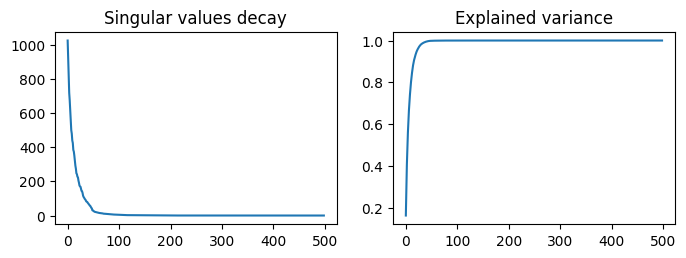

In [21]:
Xmu, smu, _ = svd(mu[:ntrain].T, full_matrices = False)

plt.figure(figsize = (8, 2.5))
plt.subplot(1, 2, 1)
plt.plot(smu[1:500])
plt.title("Singular values decay")
plt.subplot(1, 2, 2)
plt.plot(np.cumsum(smu[1:500]**2)/np.sum(smu[1:]**2))
plt.title("Explained variance")
plt.show()

In [22]:
psmall = 131
Z = Xmu[:, :psmall]

In [23]:
mu, Z = dv.tensor(mu, Z) # moving to torch tensors

In [24]:
mu_small = mu @ Z # reduced input
c = u @ V # reduced output

In [26]:
psi = DFNN(Dense(psmall, 50, gelu) + Dense(50, n, activation = None))
psi.He()
psi.moveOn(dv)
psi.train(mu_small, c, ntrain = ntrain, epochs = 500, loss = mse(euclidean))

		Train		Test
Epoch 500:	4.46e+00	7.09e+00.

>> ETA: 0.28s.

Training complete. Elapsed time: 2 minutes 21.90 seconds.


In [27]:
psi.freeze()
pcanet = lambda mu0 : psi(mu0 @ Z) @ V.T

In [28]:
print("MRE for PCA-Net: %s." % num2p(mrei(l2)(u[ntrain:], pcanet(mu)[ntrain:])))

MRE for PCA-Net: 6.55%.


### POD-MINN: enhancing POD-NN with Mesh-Informed Neural Networks

An alternative approach is to "remain faithful" to the POD-NN framework and directly construct a suitable neural network model $\phi:\mathbb{R}^{p}\to\mathbb{R}^{n}$ such that

$$\phi(\boldsymbol{\mu})\approx\mathbf{V}^\top\mathbf{u}_{\boldsymbol{\mu}}.$$

As we mentioned, however, this is highly nontrivial. In this case, in fact, we have $p=N_h$. Implementing a plain POD-NN using Dense layers only is possible but may result in severe overfitting. See, e.g., the attempt below.

In [29]:
p = mu.shape[-1]
phidense = DFNN(Dense(p, 131) + Dense(131, 50, gelu) + Dense(50, n, activation = None))
phidense.He()
phidense.moveOn(dv)
phidense.train(mu, c, ntrain = ntrain, epochs = 500, loss = mse(euclidean))

phidense.freeze()
podnn = lambda mu0: phidense(mu0) @ V.T
print("MRE for plain POD-NN: %s." % num2p(mrei(l2)(u[ntrain:], podnn(mu)[ntrain:])))

		Train		Test
Epoch 500:	3.51e+00	1.59e+01.

>> ETA: 0.62s.

Training complete. Elapsed time: 5 minutes 9.54 seconds.
MRE for plain POD-NN: 7.64%.


To overcome this issue we can replace dense layers with sparse layers, which intrinsically have less weights and are thus less likely to overfit.

In particular, in this case where $p=N_h$ and the input is a spatially distributed field, we can rely upon **Mesh-Informed Neural Networks (MINNs)**.

MINNs are built using mesh-informed layers, which, differently from classical layers, give a precise geometric meanining to "neurons". For instance, while a dense layer from $\mathbb{R}^{N_h}$ to $\mathbb{R}^m$ will simply map an $N_h$-dimensional vector to an $m$-dimensional one, a mesh-informed layer will do the same but it will also interpret those **vectors as functions**. Specifically, it will do the equivalent of mapping a function defined over $N_h$ nodes to another one defined over $m$ nodes.

- Dense layer: $N_h$-vectors to $m$-vectors;
- Mesh-informed layer: function defined over $N_h$ nodes to function defined over $m$ nodes;

While this formulation is just a mathematical equivalent, the perspective adopted by mesh-informed layers comes with additional structure, which we can use to enforce sparsity constraints. **For instance, we may require that nodes at output only receive information from nodes at input that are nearby**. This notion of localy can be tuned using a hyperparameter called *support*.

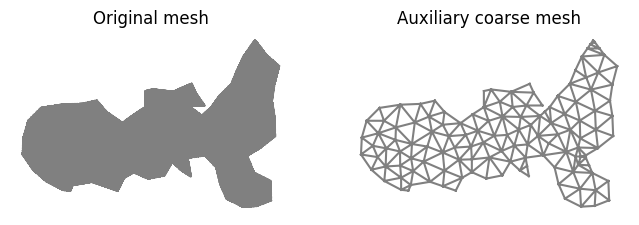

In [30]:
gdown.download(id = "1_ESzq4c-Q68dImt-WE7G_3PxYduPejBD", output = "elba_coarse_mesh.xml")
cmesh = fe.loadmesh("elba_coarse_mesh.xml")
clc()

plt.figure(figsize = (8, 3))
plt.subplot(1, 2, 1)
fe.plot(mesh)
plt.title("Original mesh")

plt.subplot(1, 2, 2)
fe.plot(cmesh)
plt.title("Auxiliary coarse mesh")
None

In [31]:
Vc = fe.space(cmesh, 'CG', 1)
clc()

Vc.dim()

131

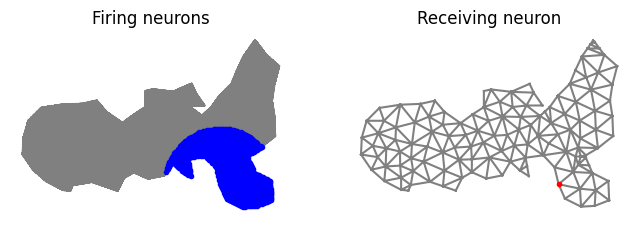

In [56]:
xh = fe.dofs(Vh)
xc = fe.dofs(Vc)

mesh_informed_layer = Local(xh, xc, support = 0.2, activation = gelu)
mesh_informed_layer.He()

i_out = 50
j_in = mesh_informed_layer.W()[:, i_out]!=0

xout = xc[i_out]

j_in = j_in.cpu().numpy()
plt.figure(figsize = (8, 3))
plt.subplot(1, 2, 1)
fe.plot(mesh)
plt.plot(xh[j_in, 0], xh[j_in, 1], '.b')
plt.title("Firing neurons")

plt.subplot(1, 2, 2)
fe.plot(cmesh)
plt.plot(*xout, '.r')
plt.title("Receiving neuron")
None

In [62]:
mesh_informed_layer.dof(), mesh_informed_layer.dof() / (p*131)

(np.int64(317952), np.float64(0.25414811558291034))

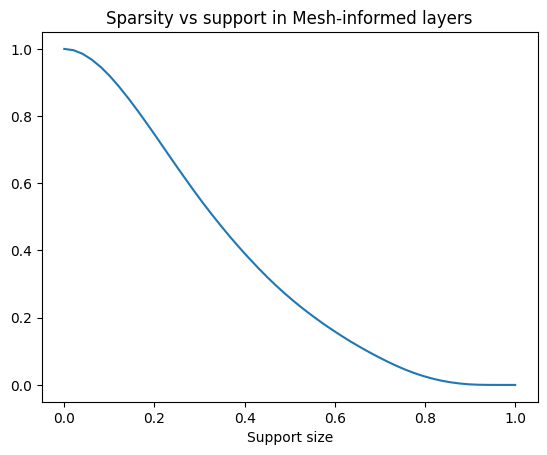

In [70]:
sparsity = lambda layer: 1.0 - layer.dof() / (layer.in_d*layer.out_d)
supports = np.linspace(0, 1, 50)
sparsities = [sparsity(Local(xh, xc, support = r)) for r in supports]
plt.plot(supports, sparsities)
plt.xlabel("Sparsity")
plt.xlabel("Support size")
plt.title("Sparsity vs support in Mesh-informed layers")
plt.show()

<mark>**Exercise 2**</mark></br>
Implement, train and assess a POD-MINN ROM.

In [35]:
minn = DFNN(Local(xh, xc, support = 0.1, activation = gelu) + Dense(131, 50, activation = gelu) + Dense(50, n, activation = None))
minn.He()
minn.moveOn(dv)
minn.train(mu, c, ntrain = ntrain, epochs = 500, loss = mse(euclidean))

		Train		Test
Epoch 500:	2.95e-01	5.60e-01.

>> ETA: 0.33s.

Training complete. Elapsed time: 2 minutes 43.30 seconds.


In [36]:
minn.freeze()
podminn = lambda mu0: minn(mu0) @ V.T

print("MRE for POD-MINN: %s." % num2p(mrei(l2)(u[ntrain:], podminn(mu)[ntrain:])))

MRE for POD-MINN: 2.69%.


## Comparison at inference

<mark>**Exercise 3**</mark></br>
Compare FOM solutions vs PCA-Net, (plain) POD-NN and POD-MINN approximations. To this end:
- focus over a single instance part of the test and compare the outputs visually (plot);
- how are the relative errors distributed across the test set? Compare the three approaches using a boxplot.



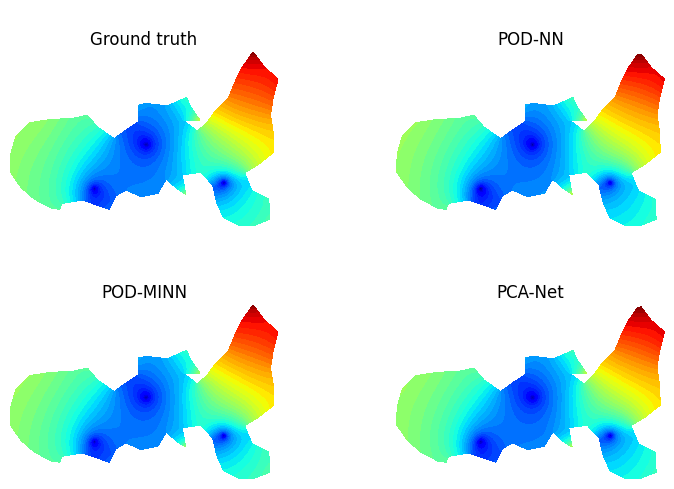

In [42]:
j = ntrain
vmin, vmax = u[j].min(), u[j].max()
plt.figure(figsize = (8, 5))
plt.subplot(2, 2, 1)
fe.plot(u[j], Vh, levels = 50, vmin = vmin, vmax = vmax)
plt.title("\nGround truth")

plt.subplot(2, 2, 2)
fe.plot(podnn(mu[j]), Vh, levels = 50, vmin = vmin, vmax = vmax)
plt.title("\nPOD-NN")

plt.subplot(2, 2, 3)
fe.plot(podminn(mu[[j]])[0], Vh, levels = 50, vmin = vmin, vmax = vmax)
plt.title("\n\nPOD-MINN")

plt.subplot(2, 2, 4)
fe.plot(pcanet(mu[j]), Vh, levels = 50, vmin = vmin, vmax = vmax)
plt.title("\n\nPCA-Net")

plt.tight_layout()

In [47]:
errors = dict()

for label, model in zip(["PCA-Net", "POD-NN", "POD-MINN"], [pcanet, podnn, podminn]):
  errors[label] = (l2(u[ntrain:] - model(mu[ntrain:]))/l2(u[ntrain:])).cpu().numpy()

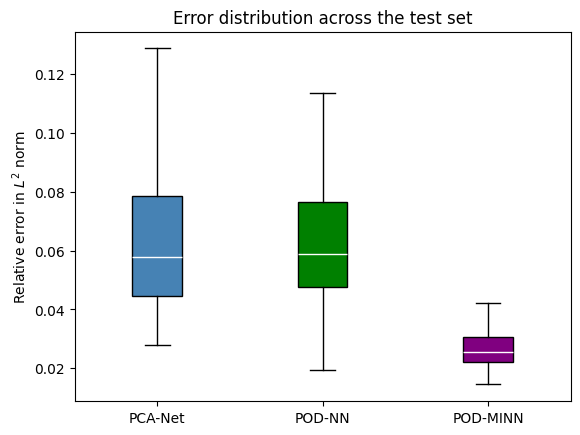

In [50]:
boxplot(errors, colors = ['steelblue', 'green', 'purple'], outliers = False)
plt.ylabel("Relative error in $L^2$ norm")
plt.title("Error distribution across the test set")
plt.show()